# Lista de Exercício 3
### Introdução à Visão Computacional (SEL0339/SEL5886)

**Instruções:**

 1. Esta lista consiste em 4 exercícios.
 1. Deve-se colocar comentários nos códigos desenvolvidos.
 1. As perguntas devem ser respondidas também como comentários no arquivo.
 1. Colocar seu nome e número USP abaixo.
 1. Quaisquer problemas na execução das listas, entrar em contato com os monitores.
 1. Depois de terminado os exercícios, deve ser gerado um arquivo **extensão .ipynb** para ser enviado ao professor pelo E-DISCIPLINAS da disciplina até a data máxima de entrega.
 1. Caso não seja enviado, o aluno ficará sem nota.


---



 <table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_3.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Executar no Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/blob/main/praticas/Lista_de_Exercicio_3.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />Ver codigo fonte no GitHub</a>
  </td>
</table>


`Nome: Marcus Vinícius Costa Reis`

`Número USP: 12549384`


### Introdução:


Vamos importar as bibliotecas que iremos utilizar:

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

from skimage.transform import hough_circle, hough_circle_peaks

#### **Atenção**: os códigos abaixo são para fazer o download das imagens (EXECUTE-OS). Os mesmos não fazem parte dessa prática.

In [39]:
import urllib.request


try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_03/wirebond_mask.tif", "wirebond_mask.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_03/house.tif", "house.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_03/abobora.tif", "abobora.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")

try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_03/sudoku.tif", "sudoku.tif")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")


try:
  urllib.request.urlretrieve("https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_03/cores.jpeg", "cores.jpeg")
except:
  print("[ERRO] Não foi possível fazer o download das imagens dessa prática. Entre em contato com o monitor")



## 1) Detector de bordas

#### 1.1) Prewitt e Sobel (Nota 1.5/10)

1. Aplicar os detectores de bordas **verticais e horizontais** de Prewitt na imagem ```wirebond_mask.tif```. Mostre a imagens original e as resultantes em um subplot.

2. Aplicar os detectores de bordas **verticais e horizontais** de Sobel na imagem ```wirebond_mask.tif```. Mostre a imagens original e as resultantes em um subplot.

2. Comente os resultados encontrados.

**Dicas:**

* Nós criamos uma lista contendo os *kernels* de cada método. Note que vários *kernels* foram fornecidos abaixo. Alguns serão utilizados no próximo exercício também.
* Você pode criar um laço de repetição para pegar cada kernel da lista. Segue abaixo um exemplo de um `for loop` em uma lista.

``` python
kernel_lista = [kernel1,kernel2,kernel3]
for kernel in kernel_lista:
  print(kernel)

```

In [40]:
# Prewitt
p1 = np.array(((-1,-1,-1),
               ( 0, 0, 0),
               ( 1, 1, 1)))

p2 = np.array(((-1, 0, 1),
               (-1, 0, 1),
               (-1, 0, 1)))

# Lista com todos os kernels (Prewitt)
prewitt = [p1,p2]

# Sobel
s1 = np.array(((-1,-2,-1),
               ( 0, 0, 0),
               ( 1, 2, 1)))

s2 = np.array(((-1, 0, 1),
               (-2, 0, 2),
               (-1, 0, 1)))

s3 = np.array(((-2,-1, 0),
               (-1, 0, 1),
               ( 0, 1, 2)))

s4 = np.array((( 0, 1, 2),
               (-1, 0, 1),
               (-2,-1, 0)))

s5 = np.array((( 2, 1, 0),
               ( 1, 0,-1),
               ( 0,-1,-2)))

s6 = np.array((( 0,-1,-2),
               ( 1, 0,-1),
               ( 2, 1, 0)))

# Lista com todos os kernels (Sobel)
sobel = [s1,s2,s3,s4,s5,s6]

# Laplaciano
laplaciano = np.array(((-1,-1,-1),
                       (-1, 8,-1),
                       (-1,-1,-1)))

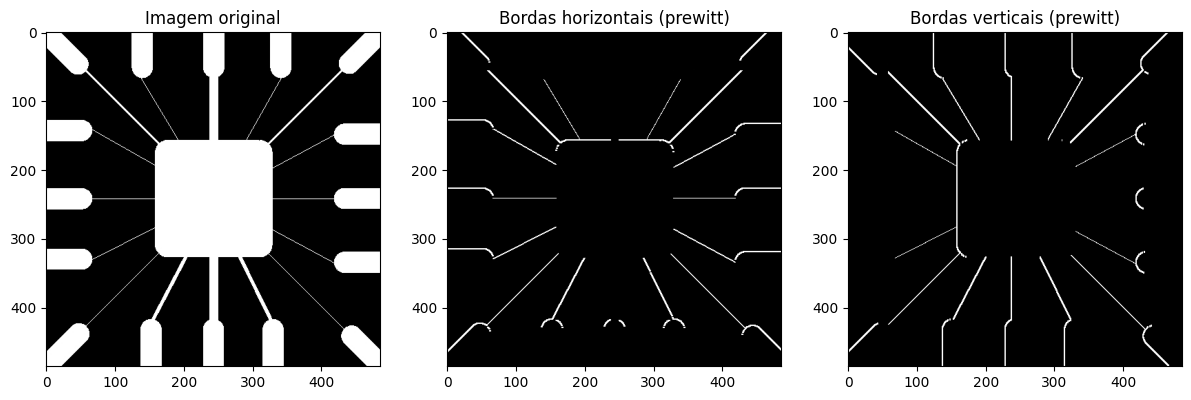

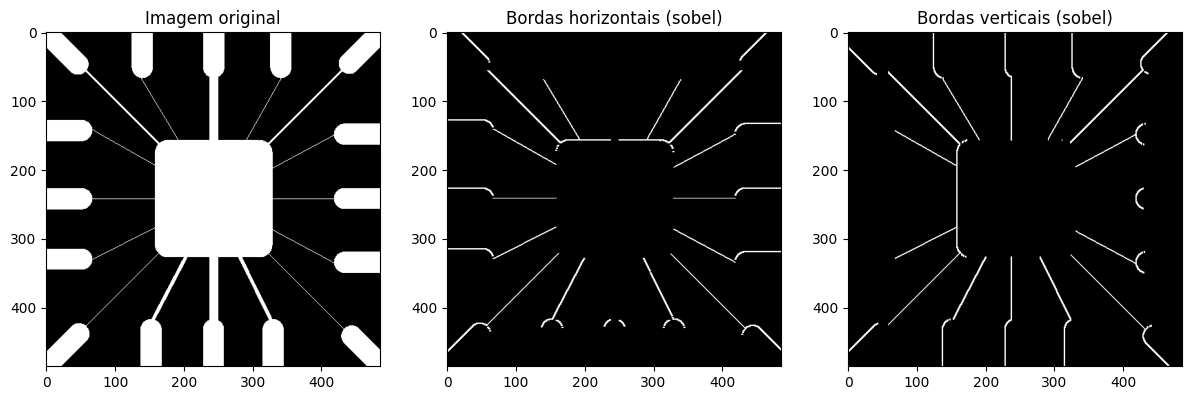

In [41]:
## -- Seu código começa AQUI -- ##

# Carregando a imagem
img = cv.imread("wirebond_mask.tif")

# Item 1 ------------------------------------------------------------------------------------

bordas_prewitt = list()  # Lista que armazena as imagens resultantes da detecção por Prewitt

# Aplicação dos kernels na imagem para detecção das bordas horizontais e verticais
for kernel in prewitt:
  bordas_prewitt.append(cv.filter2D(img, -1, kernel))

# Mostrando as imagens
plt.figure(figsize=(25, 5))

plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("Imagem original")

plt.subplot(1, 5, 2)
plt.imshow(bordas_prewitt[0])
plt.title("Bordas horizontais (prewitt)")

plt.subplot(1, 5, 3)
plt.imshow(bordas_prewitt[1])
plt.title("Bordas verticais (prewitt)")

plt.show()

# Item 2 --------------------------------------------------------------------------------

bordas_sobel = list()  # Lista que armazena as imagens resultantes da detecção por Sobel

# Aplicação dos kernels na imagem para detecção das bordas horizontais e verticais
for kernel in sobel:
  bordas_sobel.append(cv.filter2D(img, -1, kernel))

# Mostrando as imagens
plt.figure(figsize=(25, 5))

plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title("Imagem original")

plt.subplot(1, 5, 2)
plt.imshow(bordas_sobel[0])
plt.title("Bordas horizontais (sobel)")

plt.subplot(1, 5, 3)
plt.imshow(bordas_sobel[1])
plt.title("Bordas verticais (sobel)")

plt.show()

# Item 3 -------------------------------------------------------------------------

# Comentários : Primeiro, vale ressaltar que foi utilizada a função cv.filter2D
# para aplicar os detectores de borda, já que tal função realiza correlação cruzada,
# justamente o que os detectores precisam. Quanto à semelhança entre os dois detectores,
# de prewitt e de sobel, pode-se dizer que ficaram bastante similares, com a diferença
# de que algumas linhas ficaram um pouco mais espessas com o uso do sobel, quando comparadas
# às das imagens obtidas com prewitt.

## -- Seu código termina AQUI -- ##

#### 1.2) Sobel e Laplaciano (Nota 1.5/10)

1. Leia a imagem ```house.tif```. Mostre a imagem na tela.
2. Aplique todos os detectores de bordas de Sobel na imagem lida no item 1. Mostre as imagens resultantes em um subplot.
2. Para cada *kernel*, aplique um *threshold* no resultado do filtro a fim de tentar manter somente as bordas que aquele filtro foi desenvolvido para detectar (nas dicas deixamos um valor sugerido). Mostre as imagens resultantes em um subplot.
3. Some o resultado obtido por cada *kernel* (após a aplicação do *threshold* ) em uma variável chamada  ```sobel_sum ```.
3. Aplique o detector de bordas Laplaciano na imagem ```house.tif```. Mostre em um subplot a imagem original, a soma de todos os resultados de Sobel (```sobel_sum```) e o resultado do Laplaciano (lembre-se de colocar título nas imagens). O que se pode concluir?

**Dicas:**

* O valor de *threshold* sugerido é 220. Observe que para cada kernel, deve-se encontrar um valor mais adequado.

*  Faça um ```for loop``` para aplicar os filtros de Sobel. Isso simplifica o código.

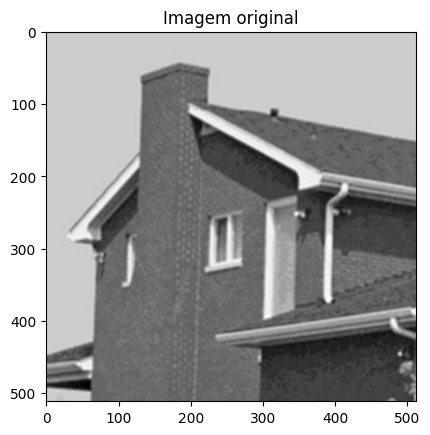

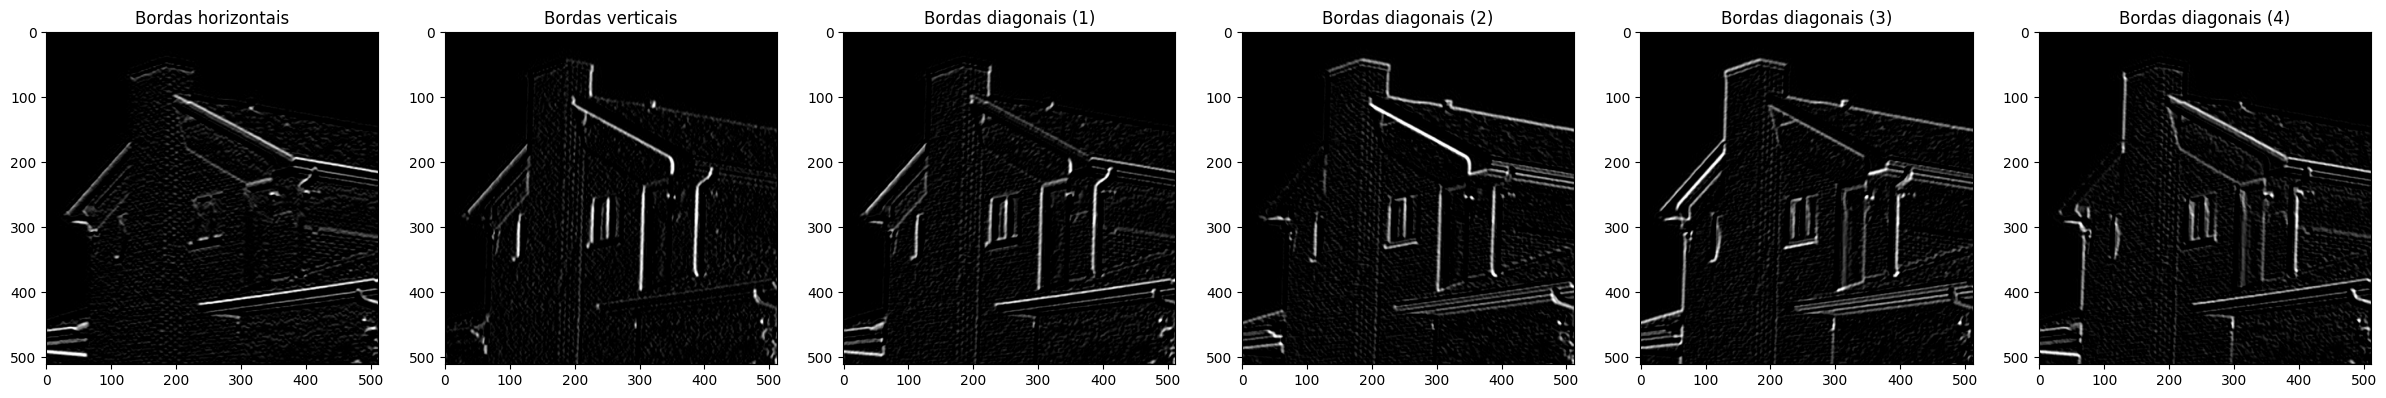

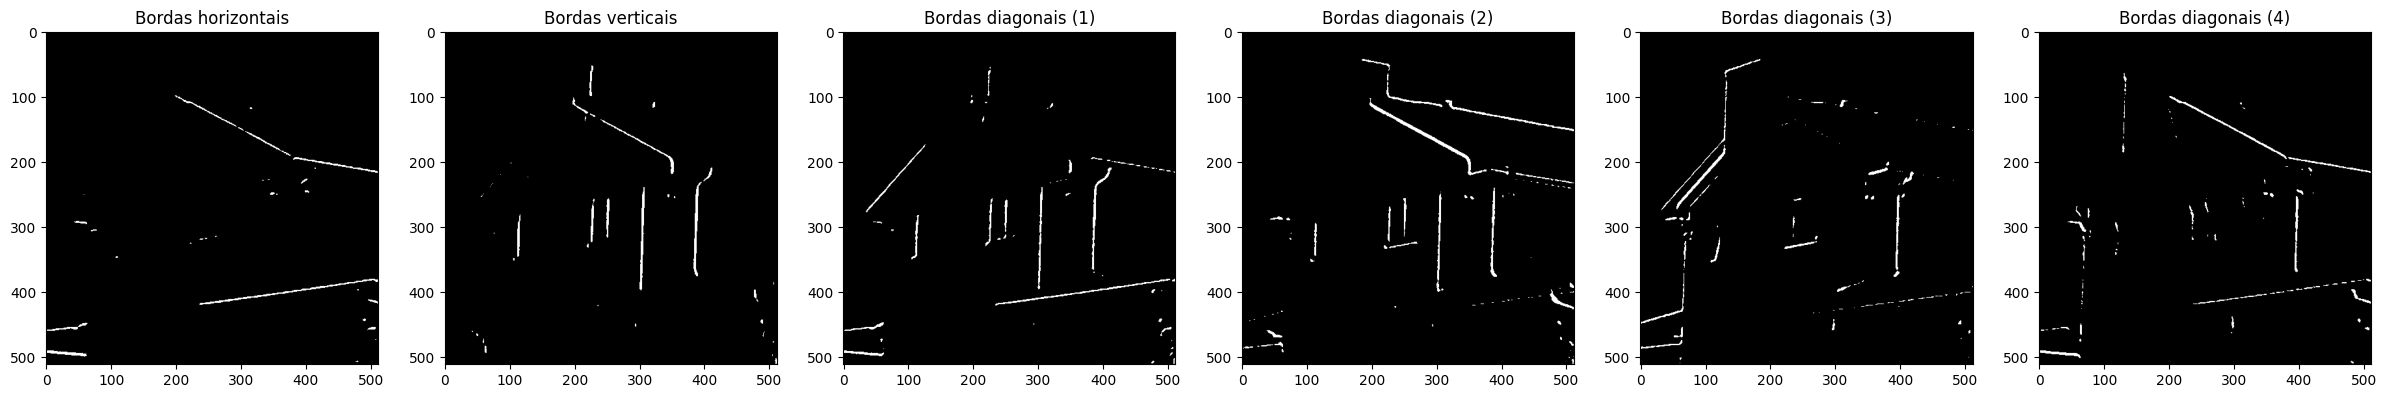

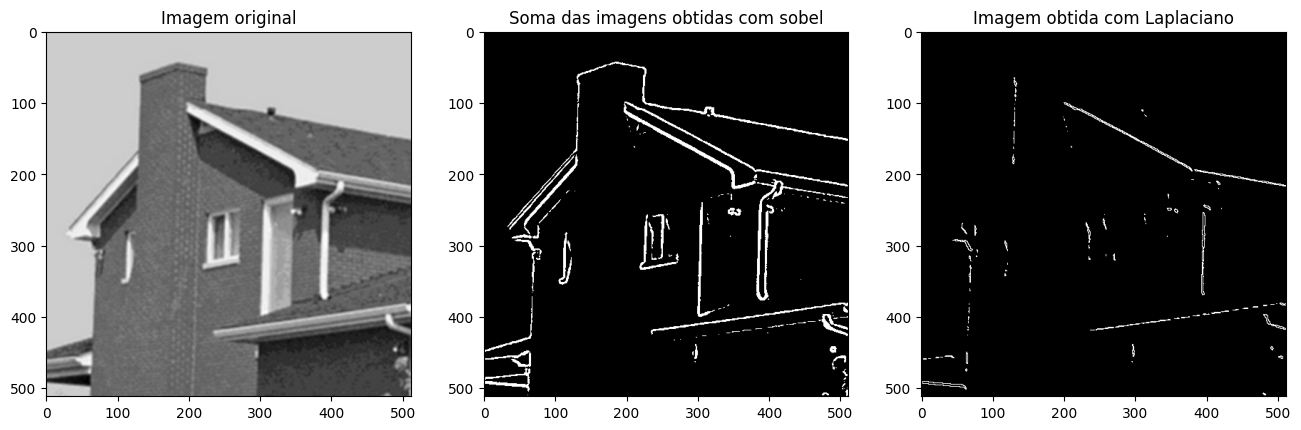

In [58]:
## -- Seu código começa AQUI -- ##

# Item 1 -----------------------------------------------------------------

# Carregando a imagem
img = cv.imread("house.tif")
aux = img  # Copiando em outra variável

# Mostrando a imagem
plt.figure()
plt.imshow(img)
plt.title("Imagem original")
plt.show()

# Item 2 -----------------------------------------------------------------

bordas_sobel = list()

# Aplicação dos kernels na imagem para detecção das bordas horizontais e verticais
for kernel in sobel:
  bordas_sobel.append(cv.filter2D(img, -1, kernel))

# Mostrando todas as imagens resultantes da correlação cruzada com os kernels de sobel
plt.figure(figsize=(30, 5))

legendas = ["Bordas horizontais", "Bordas verticais", "Bordas diagonais (1)",
            "Bordas diagonais (2)", "Bordas diagonais (3)", "Bordas diagonais (4)",]

for k, img in enumerate(bordas_sobel):
  plt.subplot(1, 6, k + 1)
  plt.title(legendas[k])
  plt.imshow(img)

plt.show()

# Item 3 -----------------------------------------------------------------

thresholds = [162, 155, 145, 133, 147, 150]  # Array de thresholds

copies = list()  # Array de cópias

for img in bordas_sobel:  # Armazenando as cópias
  copies.append(img.copy())

for j, copy in enumerate(copies):
  for k, value in np.ndenumerate(copy):  # Binarizando
    if np.max(value) <= thresholds[j]:
      copy[k] = 0
    else:
      copy[k] = 255

# Mostrando todas as imagens resultantes da correlação cruzada com os kernels de sobel
plt.figure(figsize=(30, 5))

for k, img in enumerate(copies):
  plt.subplot(1, 6, k + 1)
  plt.title(legendas[k])
  plt.imshow(img)

plt.show()

# Item 4 -----------------------------------------------------------------

sobel_sum = np.zeros(shape=img.shape)  # Inicializando a matriz soma

# Somando as imagens e armazenando na matriz sobel_sum
for copy in copies:
  sobel_sum += copy

# Item 4 -----------------------------------------------------------------

# Realizando correlação cruzada com o kernel laplaciano
img_lap = cv.filter2D(img, -1, laplaciano)

# Mostrando as imagens requeridas
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.title("Imagem original")
plt.imshow(aux)

plt.subplot(1, 3, 2)
plt.title("Soma das imagens obtidas com sobel")
plt.imshow(sobel_sum)

plt.subplot(1, 3, 3)
plt.title("Imagem obtida com Laplaciano")
plt.imshow(img_lap)

plt.show()

# COMENTÁRIOS: como se faz notável, a soma das imagens obtidas com sobel pôde
# segmentar melhor as bordas da imagem, quando comparada à imagem obtida com o
# Laplaciano.

## -- Seu código termina AQUI -- ##

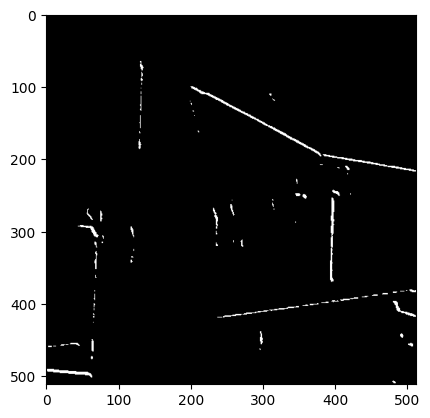

In [43]:
# DICA: você pode usar um espaço como este para simular os melhores thresholds para cada kernel.

#@title Teste Threshold{ run: "auto" }

Threshold = 150 # @param {"type":"slider","min":0,"max":255,"step":1}

## -- Seu código começa AQUI -- ##

copy = bordas_sobel[5].copy()  # Realizando uma cópia da imagem

for k, value in np.ndenumerate(bordas_sobel[5]):  # Binarizando, acessando pc_copy como numpy array

  if np.max(value) <= Threshold:
    copy[k] = 0
  else:
    copy[k] = 255

plt.figure()
plt.imshow(copy)

## -- Seu código termina AQUI -- ##

## 2) Influência da iluminação na segmentação (Nota 2.0/10)

<center><img src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_03/abobora_.png" width="256" height="256"></center>

<center><caption><b> Figura 1:</b> Imagem abobora.tif.</b></caption></center>

1. Utilize o método de Otsu para binarizar a imagem `abobora.tif`.
2. Divida a imagem em 8, 32, 64 e 256 sub-imagens, aplique o método de Otsu em cada uma delas e remonte a imagem final (tenha em mente que a divisão deve ser feita de forma a segmentar em sub-regiões com o máximo de características semelhantes, de forma a se aproveitar da melhor forma o método utilizado).
3. Apresente a imagem original e os resultados dos itens 1 e 2 em um subplot. Coloque título em cada plot.
4. Comente os resultados obtidos.

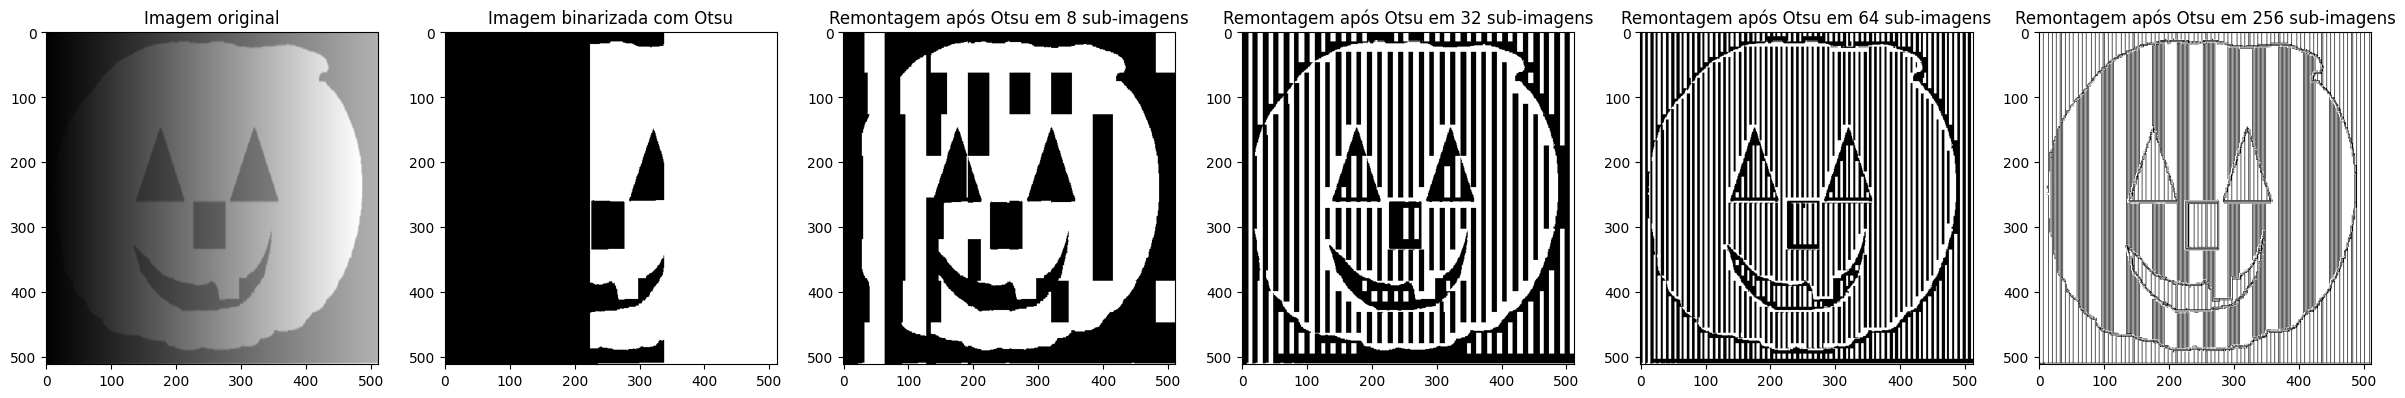

In [44]:
## -- Seu código começa AQUI -- ##

# Carregando a imagem
img = cv.imread("abobora.tif")

# Item 1  ------------------------------------------------------------------------

# Passando para grayscale de forma a possibilitar o uso do THRESH_OTU
imgg = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Utilizando o método de Otsu
th_value, imgb = cv.threshold(imgg, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Item 2  ------------------------------------------------------------------------

# Array com as divisões a serem feitas na imagem
subs = [8, 32, 64, 256]

imgs = []  # Array que armazenará as imagens resultantes

# Realizando o processo: divisão em sub-imagens, aplicação do método de Otsu em cada
# uma delas, remontagem da imagem, armazenamento no array imgs
for sub in subs:
    # Calculando a altura e largura de cada sub-imagem
    h, w = imgg.shape[:2]
    hh, ww = h//sub, w//sub

    imgf = np.zeros(shape=imgg.shape)  # Imagem que será utilizada na remontagem

    # Extraindo cada sub-imagem, aplicando Otsu, adicionando na img a ser remontada
    for j in range(sub):
        for k in range(sub):
            # Extraindo a sub-imagem
            sub_img = imgg[j*hh:(j + 1)*hh, k*ww:(k + 1)*ww]

            # Aplicando Otsu
            th_value, sub_imgb = cv.threshold(sub_img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

            # Retornando a sub-imagem binarizada à matriz imgf
            imgf[j*hh:(j + 1)*hh, k*ww:(k + 1)*ww] = sub_imgb

    imgs.append(imgf)

# Item 3  ------------------------------------------------------------------------

# Mostrando as imagens
plt.figure(figsize=(30, 5))

plt.subplot(1, 6, 1)
plt.imshow(img)
plt.title("Imagem original")

plt.subplot(1, 6, 2)
plt.imshow(imgb, 'gray')
plt.title("Imagem binarizada com Otsu")

plt.subplot(1, 6, 3)
plt.imshow(imgs[0], 'gray')
plt.title("Remontagem após Otsu em 8 sub-imagens")

plt.subplot(1, 6, 4)
plt.imshow(imgs[1], 'gray')
plt.title("Remontagem após Otsu em 32 sub-imagens")

plt.subplot(1, 6, 5)
plt.imshow(imgs[2], 'gray')
plt.title("Remontagem após Otsu em 64 sub-imagens")

plt.subplot(1, 6, 6)
plt.imshow(imgs[3], 'gray')
plt.title("Remontagem após Otsu em 256 sub-imagens")

plt.show()

# Item 4 -------------------------------------------------------------------------

# COMENTÁRIOS: como é possível perceber, a iluminação realmente influcia demasiado
# na segmentação, sobretudo quando se utiliza um método global de limiarização, como
# é o caso do método de Otsu, que produziu um resultado bem depreciado. À medida que
# se subdivide a imagem em mais sub-regiões e se aplica Otsu em cada uma das regiões,
# noe entanto, percebe-se uma melhora considerável, sobretudo na última imagem, sub-
# dividida em 256 partes.

## -- Seu código termina AQUI -- ##

## 3) Limiarização local (Nota 1.5/10)

<center><img src="https://github.com/LAVI-USP/SEL0339-SEL5886_2024/raw/main/imagens/pratica_03/sudoku_.png" width="256" height="156"></center>

<center><caption><b> Figura 2:</b> Imagem sudoku.tif.</b></caption></center>

1. A imagem `sudoku.tif` possui uma iluminação não uniforme. Aplique a binarização pelo método de limiarização local nessa imagem variando os parâmetros `blockSize` (tamanho da janela) e `C` (constante a ser diminuída da média) de forma a se obter um resultado satisfatório.

2. Aplique a binarização pelo método de Otsu e compare com o resultado obtido no item 1.

**Dicas:**

* A limiarização local pode ser feita pela função [cv.adaptiveThreshold](https://docs.opencv.org/master/d7/d1b/group__imgproc__misc.html#ga72b913f352e4a1b1b397736707afcde3). Utilize o método adaptativo `cv.ADAPTIVE_THRESH_MEAN_C` que calcula o limiar como sendo a média de uma vizinhança `blockSize x blockSize` subtraída de uma constante `C`.

``` python
# Limiarização local pela média
th3 = cv.adaptiveThreshold(img,maxVal,cv.ADAPTIVE_THRESH_MEAN_C,cv.THRESH_BINARY,blockSize,C)
```

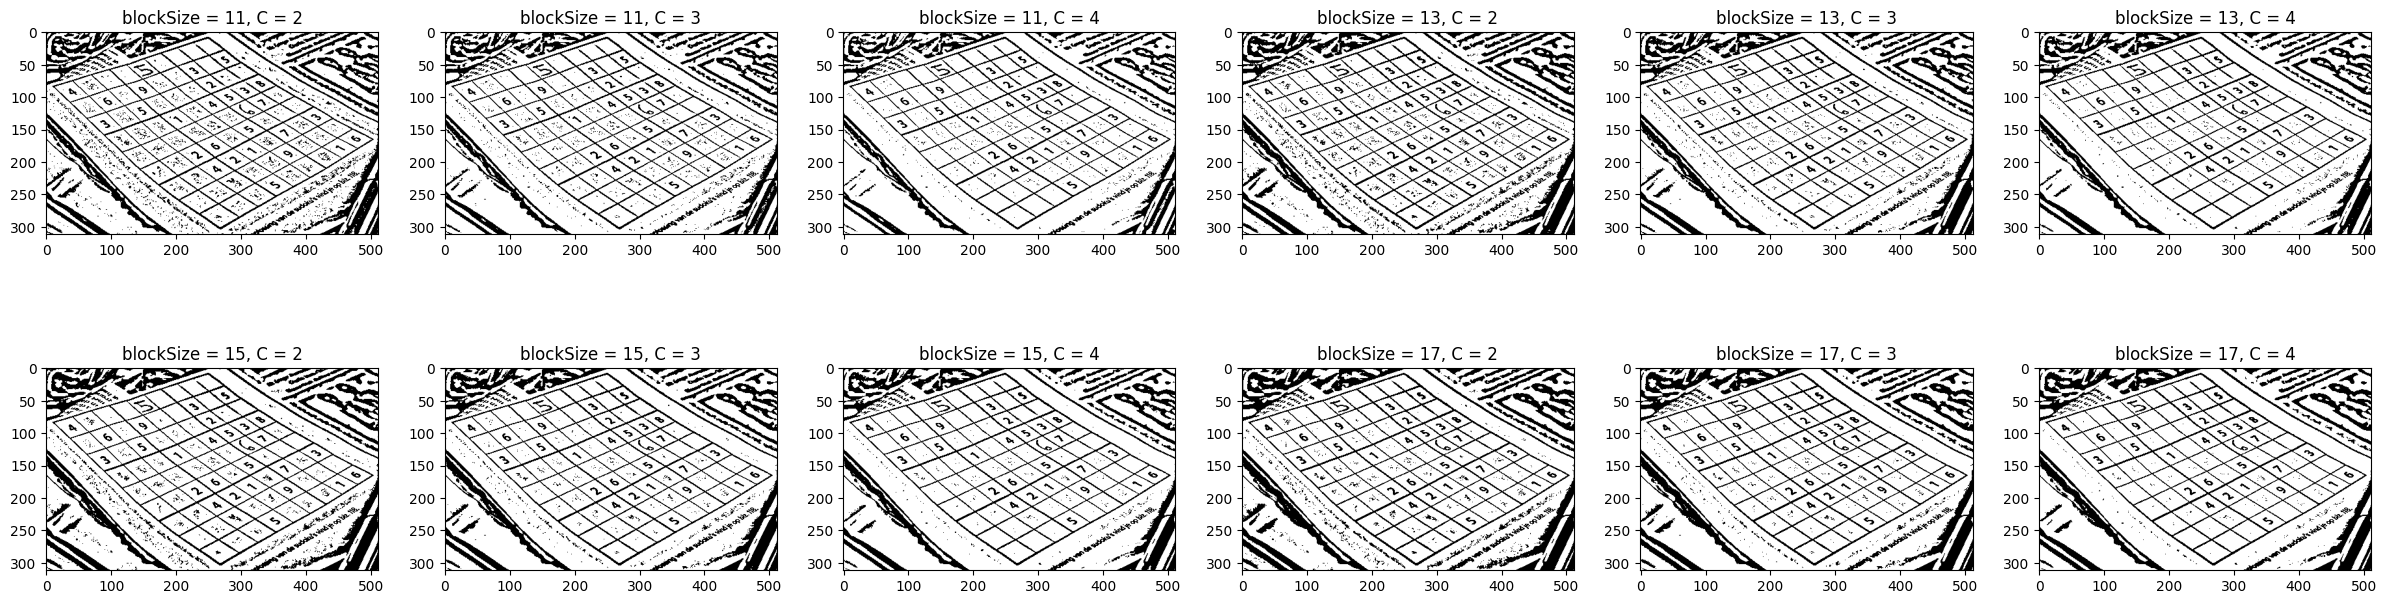

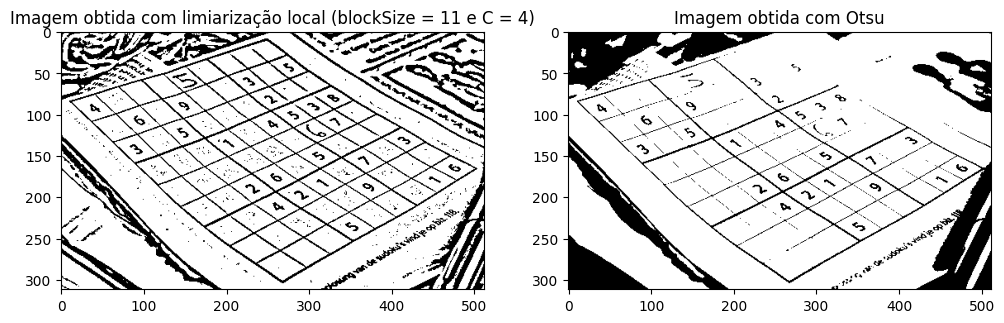

In [52]:
## -- Seu código começa AQUI -- ##

# Carregando a imagem
img = cv.imread("sudoku.tif")

# Passando para grayscale de forma a possibilitar o uso dos métodos de binarização
imgg = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Item 1 --------------------------------------------------------------------------

# Array de possíveis valores para blockSize
bs = [11, 13, 15, 17]

# Array de possíveis valores para C
cvec = [2, 3, 4]

img_lim_v = list()  # Array que armazenará as imagens resultantes

for b in bs:
  for c in cvec:
    # Aplicando a limiarização local
    img_lim = cv.adaptiveThreshold(imgg, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, b, c)
    img_lim_v.append(img_lim)  # Armazenando a imagem resultante

# Mostrando as imagens obtidas para escolher uma satisfatória
plt.figure(figsize=(30, 8))

for j, b in enumerate(bs):
  for k, c in enumerate(cvec):
    plt.subplot(2, 6, j*3 + k + 1)
    plt.title(f"blockSize = {b}, C = {c}")
    plt.imshow(img_lim_v[j*3 + k], 'gray')

plt.show()

# Item 2 --------------------------------------------------------------------------

# Aplica-se, agora, a binarização pelo método de Otsu
th_value, img_otsu = cv.threshold(imgg, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Comparando a imagem mais satisfatória obtida com a limiarização local e a imagem
# gerada pelo método de Otsu
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Imagem obtida com limiarização local (blockSize = 11 e C = 4)")
plt.imshow(img_lim_v[2], 'gray')

plt.subplot(1, 2, 2)
plt.title("Imagem obtida com Otsu")
plt.imshow(img_otsu, 'gray')

plt.show()

# COMENTÁRIOS: como fica evidente, a imagem obtida com limiarização local obteve
# uma qualidade muito superior àquela obtida com o método de Otsu, comprovando
# a eficácia da limiarização local no contexto de imagens diferentemente iluminadas.

## -- Seu código termina AQUI -- ##

## 4) K-means (Nota 3.5/10)

Neste exercício, queremos isolar os cartões coloridos da imagem `cores.jpeg`.

1. Leia e plote a imagem `cores.jpeg`.
2. Converta a imagem lida no item 1 para o espaço de cores HSV.
3. Aplique o algoritmo de K-means no canal MATIZ. Escolha o valor k mais adequado. Repare que não será possível isolar todos os cartões neste passo. Mostre os valores máximo e mínimo da imagem resultante. Comente sobre o agrupamento resultante.
4. Aplique o algoritmo de K-means no canal SATURAÇÃO. Escolha o valor k mais adequado. Repare que não será possível isolar todos os cartões neste passo. Mostre os valores máximo e mínimo da imagem resultante. Comente sobre o agrupamento resultante.
5. Transforme as imagens resultantes dos itens 3 e 4 em máscaras para isolar os cartões destacados. Ou seja, analise um valor de threshold que transforma as imagens em imagens binárias. Mostre as máscaras obtidas.
6. Faça uma operação de OR entre as duas máscaras obtidas para obter uma máscara final. Mostre esta máscara.
7. Transforme a imagem `cores.jpeg` para o espaço de cores RGB. Aplique, nesta image, a máscara obtida no item 6. Queremos que o fundo fique preto e apenas os cartões coloridos sejam mostrados na imagem.

**Dicas:**

* Você pode utilizar a função [cv.kmeans](https://docs.opencv.org/master/d5/d38/group__core__cluster.html#ga9a34dc06c6ec9460e90860f15bcd2f88) para a segmentação. Você pode utilizar 20 iterações e epsilon = 0.01 para o K-means.

* Para utilizar o K-means você deve passar a imagem como um vetor (1D). O método `.ravel()` e `.flatten()` fazem isso. Além disso, a imagem deve estar em `float32`.

* Para retornar a imagem resultante do k-means para o shape original, você pode utilizar a função `img_res.reshape(shape original)`.

``` python
criterio = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, nIteracao, epsilon)
ret,label,centers = cv.kmeans(myVector, nCluster(k), None, criterio, 5, cv.KMEANS_PP_CENTERS)

```

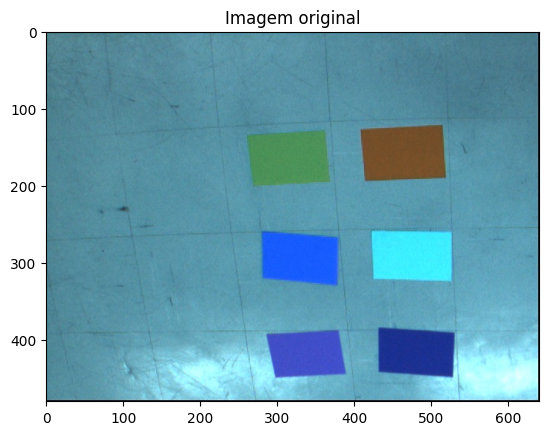

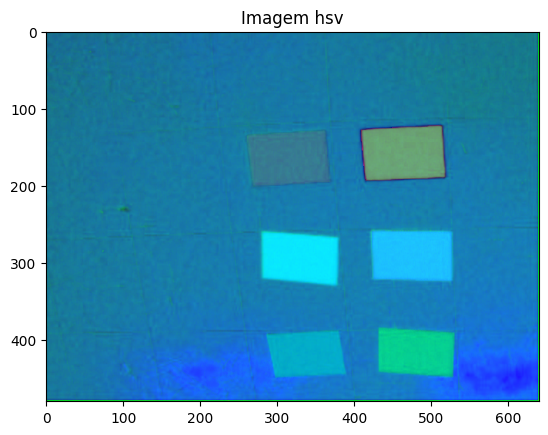

Valor mínimo da imagem: 6
Valor máximo da imagem: 104


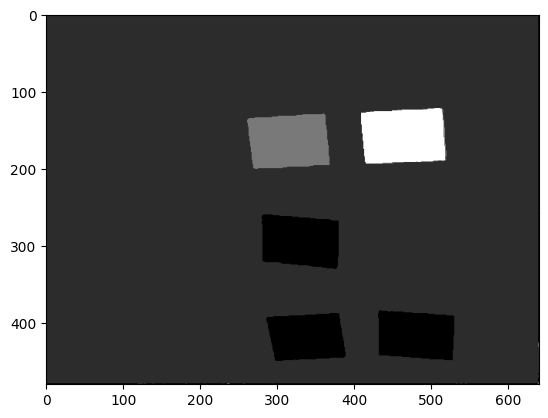

Valor mínimo da imagem: 80
Valor máximo da imagem: 222


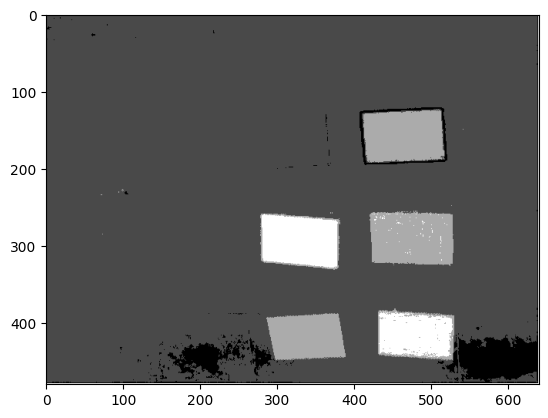

In [55]:
## -- Seu código começa AQUI -- ##

# Item 1 ---------------------------------------------------------------------

# Carregando a imagem
img = cv.imread('cores.jpeg')

# Plotando a imagem
plt.figure()
plt.imshow(img)
plt.title("Imagem original")
plt.show()

# Item 2 ---------------------------------------------------------------------

# Convertendo a imagem para o espaço de cores HSV
img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

plt.figure()
plt.imshow(img_hsv)
plt.title("Imagem hsv")
plt.show()

# Item 3 ---------------------------------------------------------------------

# Separando os canais HSV da imagem
h, s, v = cv.split(img_hsv)

# Convertendo o canal de matiz para float32, necessário para o K-means
h = h.astype(np.float32)

# Transformando o canal h em um vetor coluna (1D) para aplicar o K-means
h_vector = h.reshape(-1, 1)

# Definindo iterações e epsilon
nIteracao = 20
epsilon = 0.01

# Critério de parada
criterio = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, nIteracao, epsilon)

k = 4  # Número de clusters (k) para o K-means

# Aplicando o algoritmo K-means no vetor de matiz
ret, label, center = cv.kmeans(h_vector, k, None, criterio, 10, cv.KMEANS_RANDOM_CENTERS)

# Convertendo os centros dos clusters (cores resultantes) de volta para uint8
center = np.uint8(center)

# Atribuindo a cada pixel da imagem seu respectivo centro de cluster
res = center[label.flatten()]

# Reconstruindo a imagem binarizada com a segmentação resultante dos clusters
img_res = res.reshape((img.shape[0], img.shape[1]))

# Mostrando os valores mínimo e máximo da imagem resultante
print(f'Valor mínimo da imagem: {np.min(img_res)}')
print(f'Valor máximo da imagem: {np.max(img_res)}')

# Exibindo a imagem resultante (segmentada por clusters) em escala de cinza
plt.figure()
plt.title("Imagem segmentada por K-means no canal matiz")
plt.imshow(img_res, 'gray')
plt.show()

# Item 4 -------------------------------------------------------------------------

# Convertendo o canal de saturação para float32, necessário para o K-means
s = s.astype(np.float32)

# Transformando o canal h em um vetor coluna (1D) para aplicar o K-means
s_vector = s.reshape(-1, 1)

# Definindo iterações e epsilon
nIteracao = 20
epsilon = 0.01

# Critério de parada
criterio = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, nIteracao, epsilon)

k = 4  # Número de clusters (k) para o K-means

# Aplicando o algoritmo K-means no vetor de matiz
ret, label, center = cv.kmeans(s_vector, k, None, criterio, 10, cv.KMEANS_RANDOM_CENTERS)

# Convertendo os centros dos clusters (cores resultantes) de volta para uint8
center = np.uint8(center)

# Atribuindo a cada pixel da imagem seu respectivo centro de cluster
res = center[label.flatten()]

# Reconstruindo a imagem binarizada com a segmentação resultante dos clusters
img_res = res.reshape((img.shape[0], img.shape[1]))

# Mostrando os valores mínimo e máximo da imagem resultante
print(f'Valor mínimo da imagem: {np.min(img_res)}')
print(f'Valor máximo da imagem: {np.max(img_res)}')

# Exibindo a imagem resultante (segmentada por clusters) em escala de cinza
plt.figure()
plt.title("Imagem segmentada por K-means no canal saturação")
plt.imshow(img_res, 'gray')
plt.show()

## -- Seu código termina AQUI -- ##